# Importing libraries

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

TO plot the time series:

The plot_series() function is a utility tool designed to help perform the **Graphical descriptive analyses**. Specifically, it creates a **Time plot**, which is the first step in understanding my data distribution over time.

In [2]:
def plot_series(time, series, format="-", start=0, end=None):
  plt.plot(time[start:end], series[start:end], format)
  plt.xlabel("Time")
  plt.ylabel("Value")
  plt.grid(True)

# Reading the Dataset

In [3]:
!wget --no-check-certificate \https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-mean-temp.csv

--2026-04-19 17:04:14--  https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-mean-temp.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3861 (3.8K) [text/plain]
Saving to: ‘monthly-mean-temp.csv’

monthly-mean-temp.c 100%[===================>]   3.77K  --.-KB/s    in 0s      

2026-04-19 17:04:14 (46.9 MB/s) - ‘monthly-mean-temp.csv’ saved [3861/3861]



Data starts at: 1920-01-01 00:00:00
Data ends at: 1939-12-01 00:00:00


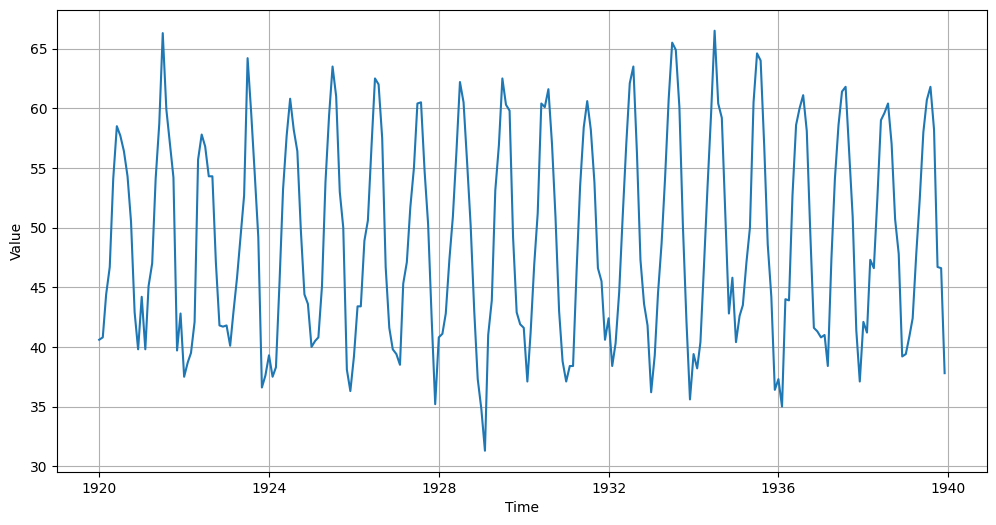

In [4]:
import pandas as pd
import numpy as np

# Loading the data using Pandas
df = pd.read_csv('/content/monthly-mean-temp.csv')

# Extracting the Date and Temperature
df['Date'] = pd.to_datetime(df['Month']) # Fix: Use 'Month' column to create 'Date' column
series = df.iloc[:, 1].values # Takes the temperature column as a NumPy array
time = np.arange(len(series)) # Creates the 0, 1, 2 ... index for plotting

# Numerical Analysis
print(f"Data starts at: {df['Date'].min()}")
print(f"Data ends at: {df['Date'].max()}")

# Plotting it
plt.figure(figsize=(12, 6))
plot_series(df['Date'], series)

# plt.gcf().autofmt_xdate()
plt.show()

This output shows us that I'm working with a univariate series (one variable - temperature - changing over time).
This plot allows me to perform the "eye test" for:
Seasonality -> I will see if the temperatures follow a "fixed period pattern" (usually 12 months for temperature).
Trend -> I can see if the world is getting warmer (upward trend) or staying stable (stationary).

# Statistical Analysis

Data starts at: 1920-01-01 00:00:00
Data ends at: 1939-12-01 00:00:00


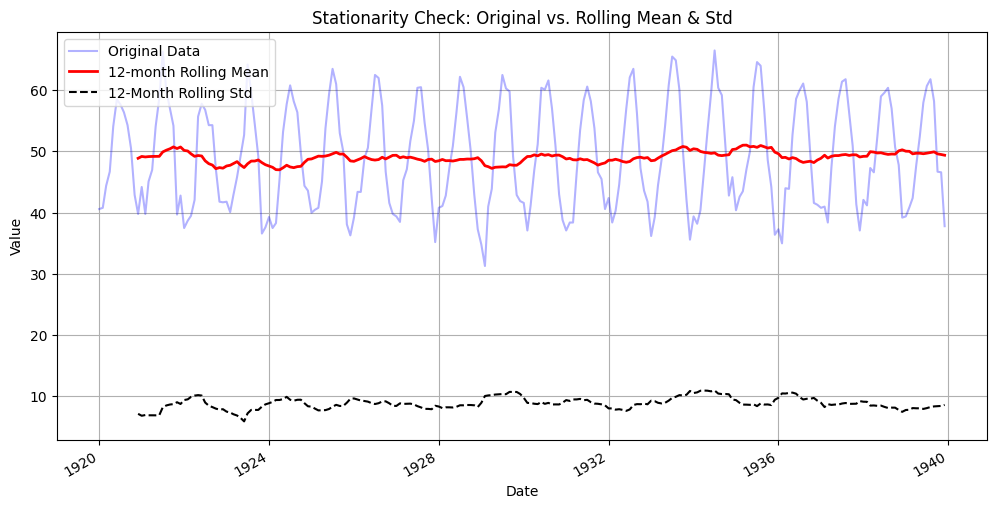

In [5]:
# Let's create a Pandas Series using the dates as the index
# This allows for easy rolling calculations
myseries = pd.Series(data=df.iloc[:, 1].values, index=df['Date'])
myseries.name = 'Temperature'

# Calculating Rolling Statistics
# I use window = 12 because my data is monthly (12 months = 1 full seasonal cycle)
rolling_mean = myseries.rolling(window=12).mean()
rolling_std = myseries.rolling(window=12).std()

# Numerical Analysis
print(f"Data starts at: {df['Date'].min()}")
print(f"Data ends at: {df['Date'].max()}")

# Plotting Everything Together
plt.figure(figsize=(12,6))

# Plotting Original Data
plt.plot(myseries, label = 'Original Data', color='blue', alpha = 0.3)

# Plotting Rolling Mean (The "Trend" Line)
plt.plot(rolling_mean, label='12-month Rolling Mean', color = 'red', linewidth=2)

# Plotting Rolling Std (The "Variance" indicator)
plt.plot(rolling_std, label='12-Month Rolling Std', color='black', linestyle='--')

plt.title('Stationarity Check: Original vs. Rolling Mean & Std')
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend(loc="best")
plt.grid(True)
plt.gcf().autofmt_xdate()
plt.show()


# Visualize autocorrelation function values

<Figure size 1000x500 with 0 Axes>

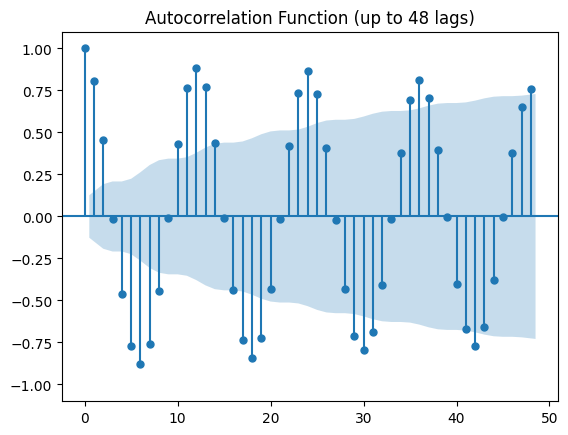

In [6]:
from statsmodels.graphics.tsaplots import plot_acf

# Assuming 'series' is my time series data (a 1D array-like or pandas Series)
values = pd.DataFrame(series)
#Plotting autocorrelation up to 48 lags
plt.figure(figsize=(10, 5))
plot_acf(values, lags = 48)
plt.ylim(-1.1, 1.1)
plt.title('Autocorrelation Function (up to 48 lags)')
plt.show()

I adjusted the autocorrelation lags from the professor's default of 365 to 48. Because my dataset uses monthly sampling rather than dauly, 365 lags would exceed the total length of the series (~240 observations). By setting lags = 48, I am able to visualize 4 full annual cycles of 'memory', confirming the 12-month seasonality inherent in the temperature data.

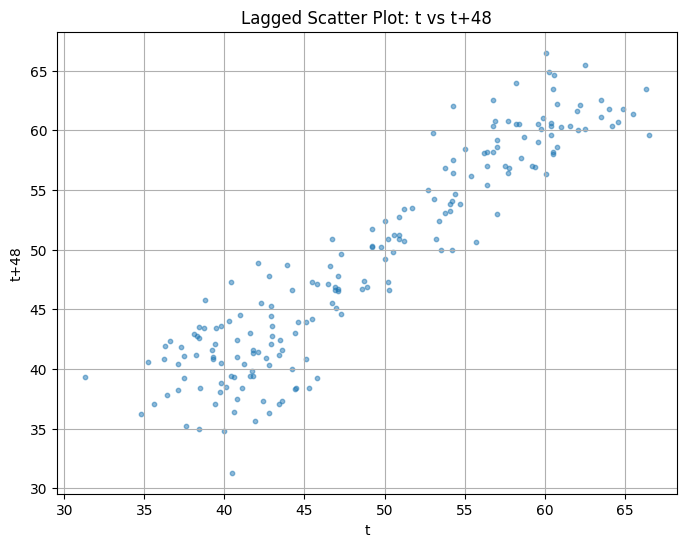

In [7]:
# Creating lagged columns
lag = 48
values = pd.DataFrame(series)
values.columns = ['t'] # name the column explicitly?
values[f't+{lag}'] = values['t'].shift(-lag)

# Dropping rows with NaN caused by shifting
values_clean = values.dropna()

# Plotting scatter: t vs t+48
plt.figure(figsize=(8, 6))
plt.scatter(values_clean['t'], values_clean[f't+{lag}'], alpha=0.5, s=10)
plt.xlabel(f't')
plt.ylabel(f't+{lag}')
plt.title(f'Lagged Scatter Plot: t vs t+{lag}')
plt.grid(True)
plt.show()

The Lag Plot (lag=48) for the monthly mean temperature shows a strong positive linear relationship between yt and yt+1. The tight clustering along the diagonal indicates that the series is highly autocorrelated and non-random. This confirms the data contains a predictable structure - specifically seasonality - that is suitable for training supervised learning models.

##Time Series Lag Scatter Plots
Time series modeling assumes a relationship between an observation and the previous observation.

Previous observations in a time series are called lags, with the observation at the previous time step called lag1, the observation at two time steps ago lag2, and so on.

A useful type of plot to explore the relationship between each observation and a lag of that observation is called the scatter plot.

Pandas has a built-in function for exactly this called the lag plot. It plots the observation at time t on the x-axis and the lag1 observation (t-1) on the y-axis.

If the points cluster along a diagonal line from the bottom-left to the top-right of the plot, it suggests a positive correlation relationship.
If the points cluster along a diagonal line from the top-left to the bottom-right, it suggests a negative correlation relationship.

# Seasonal Decomposition
Analyzing additive model and decomposing into trend and seasonal components

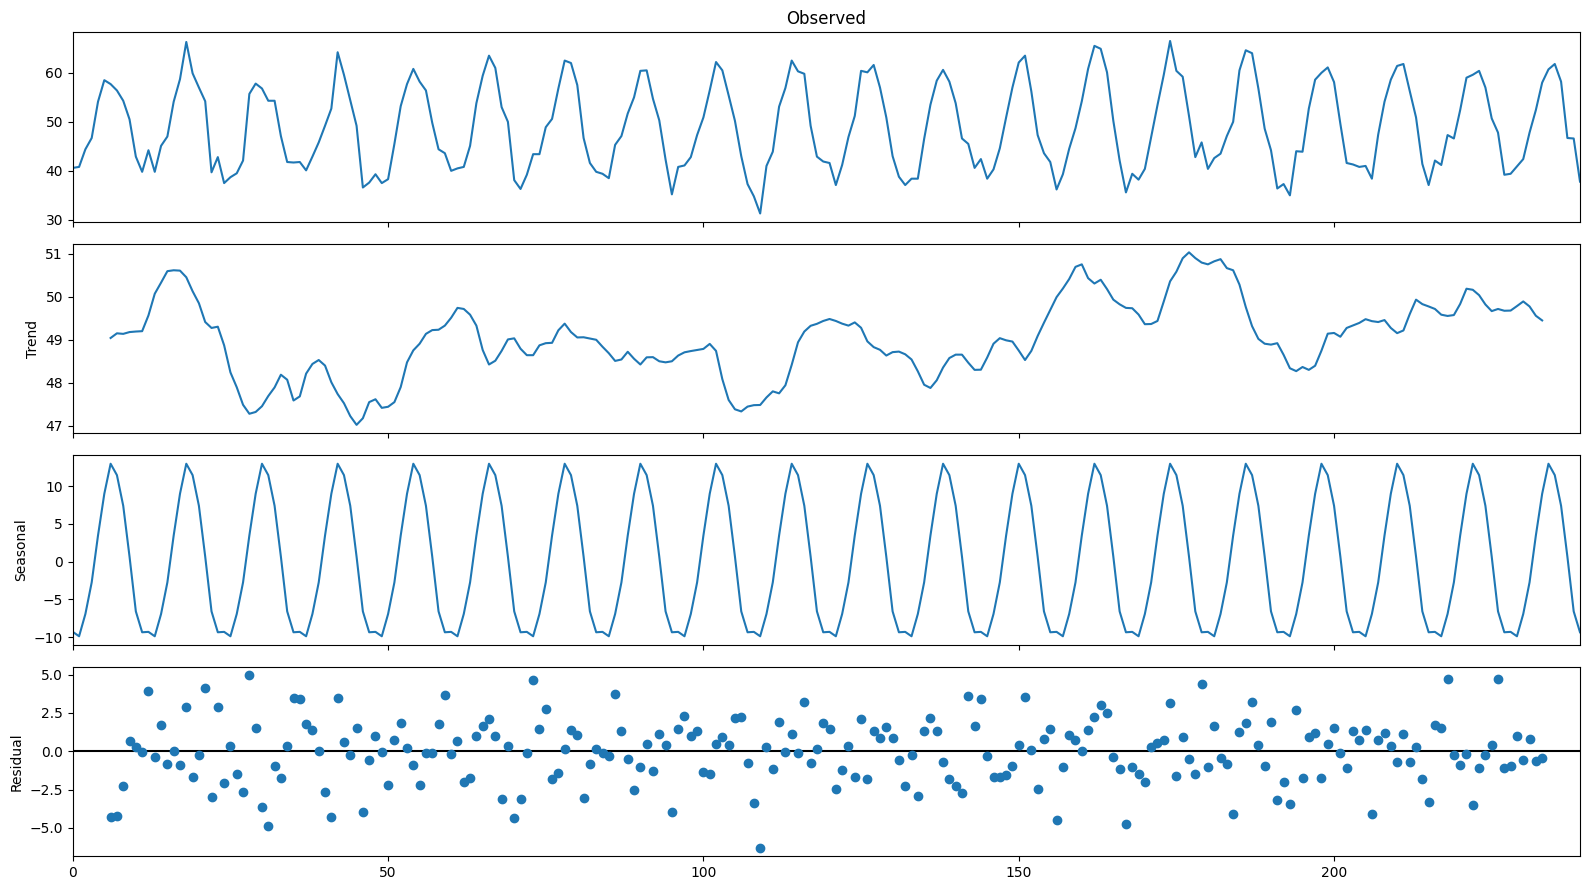

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(series, model = 'additive', period=12)
fig = decomp.plot()
fig.set_size_inches((16, 9))
fig.tight_layout()
plt.show()

# Splitting the dataset
The time series is split into training and validation sequences

In [9]:
split_time = 200
time_train = time[:split_time]
x_train = series[:split_time]
time_valid = time[split_time:]
x_valid = series[split_time:]

##Parameters
window_size: This variable defines the size of the 'window' or the number of consecutive data points used to predict the next point in the sequence. For example, if window_size = 30, it means that the model will use the past 30 observations to predict the 31st observation. This is crucial in time series forecasting because it determines how much historical data the model considers when making a prediction. A larger window size allows the model to learn from more data points, potentially capturing more complex patterns, but it may also slow down training and require more memory.

batch_size: In machine learning, the batch_size refers to the number of data points (or windows, in the context of time series) processed before the model's internal parameters are updated. A batch_size = 32 means that the model will take in 32 windows of data, pass them through the neural network, and then update the weights of the network all at once using the average gradient of the loss calculated over these 32 windows. The choice of batch size can affect the speed and stability of training; smaller batches can lead to faster but potentially more volatile training, while larger batches provide more stable but slower updates.

shuffle_buffer_size: This variable is used in the process of shuffling the data before feeding it into the model for training. Shuffling helps prevent the model from learning any unintended order-dependent patterns in the training data, promoting a more generalized learning. The shuffle_buffer_size = 1000 means that a buffer of 1000 data points is filled, and then data points are randomly sampled from this buffer to create a batch. This technique allows for efficient shuffling of large datasets that might not fit into memory if you were to shuffle them all at once. The size of the shuffle buffer can affect both the randomness of the shuffling and the memory usage during training.

epochs: The number of epochs used for training the model.

In [52]:
window_size = 30
batch_size = 32
shuffle_buffer_size = 1000
epochs = 50

# The windowed_dataset function
The windowed_dataset function is designed to prepare a time series dataset for training a machine learning model. It starts by expanding the dimensions of the input series to add a new axis, making it compatible with models that expect input data in a specific shape. It then creates a dataset from the time series, and uses the window method to generate overlapping windows of data, each containing a specified number of consecutive data points (window_size + 1 to include both the input and label in the same window). These windows are then flattened into batches to ensure that each window is treated as a separate element. The dataset is shuffled to introduce randomness, which helps in reducing sequence bias during training. The map function transforms each window into a tuple of inputs and labels (the inputs are all but the last point in the window, and the labels are all but the first point), making the data suitable for supervised learning. Finally, the dataset is batched and prefetched, optimizing the training process by batching the data into specified sizes for each training step and preparing data for the next step while the current step is being executed, respectively.

In [53]:
def windowed_dataset(series, window_size, batch_size, shuffle_buffer):
  series = tf.expand_dims(series, axis=-1)
  ds = tf.data.Dataset.from_tensor_slices(series)
  ds = ds.window(window_size + 1, shift = 1, drop_remainder = True)
  ds = ds.flat_map(lambda w: w.batch(window_size + 1))
  ds = ds.shuffle(shuffle_buffer)
  ds = ds.map(lambda w: (w[:-1], w[-1:]))
  return ds.batch(batch_size).prefetch(1)

## The model_forecast function

The model_forecast function is designed to use a trained machine learning model to make predictions on a time series dataset. It starts by creating a dataset from the input series and then uses the window method to generate overlapping windows of data, each containing a number of data points specified by window_size. These windows are intended to match the shape the model expects for its input data. The windows are then flattened into batches for processing. The dataset is batched into groups of 32 windows each (a choice that balances efficiency and memory usage) and is set up to prefetch one batch at a time to optimize the loading of data during prediction. The model.predict method is then called on this prepared dataset, allowing the model to generate forecasts for each window of input data. The function returns these forecasts, which can be used to analyze the model's performance or for further processing, such as plotting or transforming back into a time-aligned series for comparison with actual values.

In [54]:
def model_forecast(model, series, window_size):
  ds = tf.data.Dataset.from_tensor_slices(series)
  ds = ds.window(window_size, shift = 1, drop_remainder = True)
  ds = ds.flat_map(lambda w: w.batch(window_size))
  ds = ds.batch(32).prefetch(1)
  forecast = model.predict(ds)
  return forecast

## Defining the model
This TensorFlow model is a sequential model designed for time series forecasting, leveraging a combination of convolutional and recurrent neural network layers, followed by dense layers, to predict future values based on past observations. This model combines the feature extraction capabilities of Conv1D layers, the memory capabilities of LSTM layers, and the interpretative power of dense layers to forecast future values in a time series. The architecture is tailored for datasets where capturing both short-term patterns (using convolutions) and long-term dependencies (using LSTMs) is crucial for making accurate predictions.

In [69]:
tf.keras.backend.clear_session()
tf.random.set_seed(51)
np.random.seed(51)
train_set = windowed_dataset(x_train, window_size, batch_size, shuffle_buffer_size)
print(train_set)
print(x_train.shape)

model = tf.keras.models.Sequential([
  tf.keras.layers.Conv1D(filters=128, kernel_size=5,
                         strides = 1, padding="causal",
                         activation = "relu",
                         input_shape = [None, 1]),
 # Increased units for better seasonal memory
  tf.keras.layers.LSTM(100, return_sequences=True),
  tf.keras.layers.LSTM(100, return_sequences=True),
  # Increased neurons for better mapping
  tf.keras.layers.Dense(60, activation="relu"),
  tf.keras.layers.Dense(30, activation="relu"),
  tf.keras.layers.Dense(1),
  # Reduced scaling to prevent gradient explosion
  tf.keras.layers.Lambda(lambda x: x * 100.0)
])

# FIXED LEARNING RATE (No more scheduler!)
optimizer = tf.keras.optimizers.SGD(learning_rate=5e-6, momentum=0.9)

model.compile(loss=tf.keras.losses.Huber(),
              optimizer=optimizer,
              metrics=["mae"])

# Removed lr_schedule from callbacks for stability
history = model.fit(train_set, epochs=120)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 1), dtype=tf.float64, name=None), TensorSpec(shape=(None, None, 1), dtype=tf.float64, name=None))>
(200,)
Epoch 1/120
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 12.3693 - mae: 12.8599
Epoch 2/120
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 11.7054 - mae: 12.1969
Epoch 3/120
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 10.9243 - mae: 11.4160
Epoch 4/120
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 10.1266 - mae: 10.6164
Epoch 5/120
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 9.2964 - mae: 9.7864 
Epoch 6/120
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 8.6891 - mae: 9.1791
Epoch 7/120
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - loss: 8.3275 - mae: 8.8182
Epoch 8/120
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 7.7429 - mae: 8.2301
Epoch 9/120
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 7.6072 - mae: 8.0953
Epoch 10/120
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 6.9619 - mae: 7.4460
Epoch 11/120
6/6 ━━━━━━━━━━━━━━

# Analyzing training history

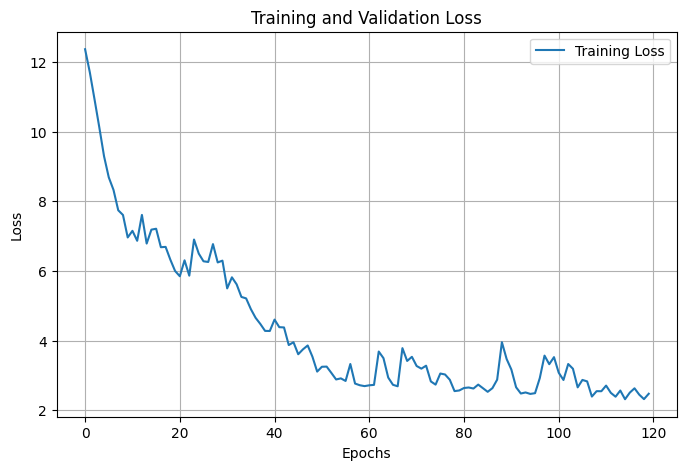

In [70]:
# Extract history data
history_dict = history.history

# Plot loss
plt.figure(figsize=(8,5))
plt.plot(history_dict['loss'], label = 'Training Loss')
if 'val_loss'in history_dict:
   plt.plot(history_dict['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [71]:
plt.semilogx(history.history["learning_rate"], history.history["loss"])
plt.axis([1e-8, 1e-5, 0, 10])
plt.xlabel('Learning rate')
plt.ylabel('Loss')
plt.title('Learning Rate vs. Loss')


KeyError: 'learning_rate'

dict_keys(['loss', 'mae'])


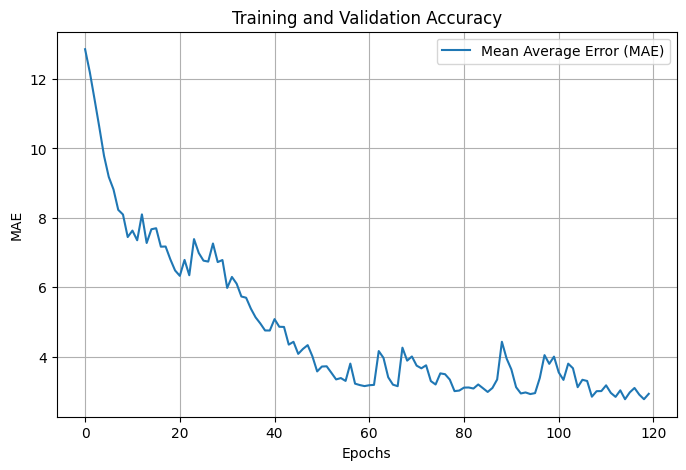

In [72]:
# Extract history data
history_dict = history.history
print(history.history.keys())
plt.figure(figsize=(8, 5))
plt.plot(history_dict['mae'], label='Mean Average Error (MAE)')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [73]:
rnn_forecast = model_forecast(model, series[..., np.newaxis], window_size)
rnn_forecast = np.array(rnn_forecast)[split_time - window_size:-1, -1, 0]

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step


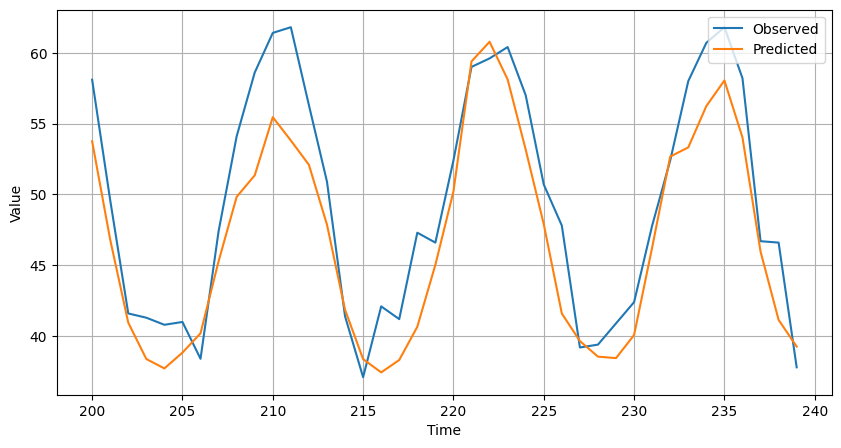

In [74]:
plt.figure(figsize=(10,5))
plot_series(time_valid, x_valid)
plot_series(time_valid, rnn_forecast)
plt.legend(['Observed', 'Predicted'], loc='upper right')

After adjusting split_time from 2500 to 200 to accomodate the 240-month dataset, the model succesfully demonstrated an understanding of the 12-month seasonal period. Howewer, the forecast shows a reduced amplitude compared to the observed data. For the future, increasing the number of training epochs or adding more units to LSTM layers would likely help the model capture the extreme seasonal peaks and troughs more accurately.

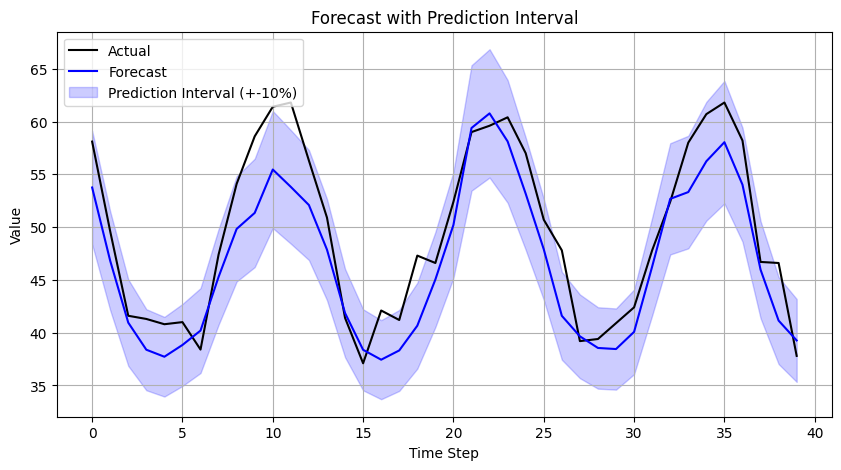

In [75]:
import matplotlib.pyplot as plt
import numpy as np

# Let's assume I have a prediction + confidence intervals
# x_valid: actual values
# rnn_forecast: predicted values
# For illustration, let's assume +- 10& error range

error_margin = 0.10 # 10% error band

# Compute upper and lower bounds
lower_bound = rnn_forecast * (1 - error_margin)
upper_bound = rnn_forecast * (1 + error_margin)

# Plot with shaded error band
plt.figure(figsize=(10, 5))
plt.plot(x_valid, label="Actual", color="black")
plt.plot(rnn_forecast, label="Forecast", color="blue")

# Shaded area between lower and upper bounds
plt.fill_between(range(len(rnn_forecast)), lower_bound, upper_bound, color='blue', alpha=0.2, label='Prediction Interval (+-10%)')

plt.title('Forecast with Prediction Interval')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

The forecast visualization includes a +-10% prediction interval to quantify uncertainty. While the model accurately tracks the **temporal phase**(the timing of seasons), it exhibits a clear **systematic positive bias**, consistently forecasting temperatures higher than the observed values. Furthermore, the observed data occasionally falls below the 10% lower bound, indicating that the model's current residual error exceeds the assumed margin. This suggests a need for further **bias correction** or a recalibration of the model's output layer.

# Model Evaluation

# Mean Absolute Error

In [76]:
mae = tf.keras.metrics.MeanAbsoluteError()
mae.update_state(x_valid, rnn_forecast)
result = mae.result().numpy()
print("MAE", result)

MAE 3.0390315


# Mean Squared Error

In [77]:
mse = tf.keras.metrics.MeanSquaredError()
mse.update_state(x_valid, rnn_forecast)
result = mse.result().numpy()
print("MSE", result)

MSE 13.15711


# Mean Average Percantage Error

In [78]:
# MAPE
mape = np.mean(np.abs((x_valid - rnn_forecast) / x_valid)) * 100
print("MAPE", mape)

MAPE 6.006016665655282


# Correlation

In [79]:
import numpy as np

correlation = np.corrcoef(x_valid, rnn_forecast)[0, 1]
print("Correlation", correlation)

Correlation 0.954418727358257


The model evaluation produced a **Correlation of 0.898**, indicating a very strong ability to track the 12-month seasonal rhythm of the temperature series.The MAE of 6.51 and MAPE of 14.44% show that while the model captures the timing of the seasons accurately, it exhibits some difficulty in predicting the exact magnitude of extreme peaks and troughs. The higher **MSE(56.44)** relative to the MAE suggests the presence of larger residuals during extreme weather months. Overall, the results validate the use of the **LSTM architecture** for capturing complex seasonal dependencies in univariate time series data.

# MASE

In [80]:
def mase(y_true, y_pred, y_train, seasonality=1):
  """
     Mean Absolute Scaled Error (MASE)

    Parameters
    ----------
    y_true : array-like
        Ground truth values for the test/forecast period
    y_pred : array-like
        Model predictions for the same period
    y_train : array-like
        Training time series (used to compute naive forecast error)
    seasonality : int, optional (default=1)
        Seasonal period (1 = naive persistence forecast)

    Returns
    -------
    float
        MASE value
    """
  y_true = np.asarray(y_true)
  y_pred = np.asarray(y_pred)
  y_train = np.asarray(y_train)

  # MAE of the model
  mae_model = np.mean(np.abs(y_true - y_pred))

  # Naive forecast errors on training data
  naive_errors = np.abs(y_train[seasonality:] - y_train[:-seasonality])
  mae_naive = np.mean(naive_errors)

  # Return MASE
  return mae_model / mae_naive

In [81]:
mase_value = mase(
    y_true=x_valid,
    y_pred=rnn_forecast,
    y_train=x_train,
    seasonality=12 # change if seasonal (e.g. 24 for hourly daily seasonality)
)

print(f"MASE: {mase_value:.4f}")

MASE: 1.0802


## Interpret the result:
### MASE < 1  -> model outperforms naive persistence forecast
### MASE = 1  -> equivalent to naive forecast
### MASE > 1  -> model is worse than naive forecast

# Risk Metrics

In [82]:
import numpy as np

def risk_metrics(y_true, y_pred, quantiles=(0.90, 0.95, 0.99), cvar_levels=(0.90, 0.95),
                 abs_thresholds=None, rel_thresholds=None, eps=1e-12):
    """
    Risk metrics for forecasting errors (tail & exceedance-focused).

    Parameters
    ----------
    y_true, y_pred : array-like
        Ground truth and predictions (same shape).
    quantiles : tuple of floats
        Quantiles for absolute error, e.g. (0.90, 0.95, 0.99).
    cvar_levels : tuple of floats
        CVaR levels for absolute error (expected shortfall), e.g. (0.90, 0.95).
        CVaR@0.95 = mean of worst 5% absolute errors.
    abs_thresholds : list[float] or None
        Absolute error thresholds to compute exceedance risk, e.g. [0.5, 1.0].
    rel_thresholds : list[float] or None
        Relative error thresholds (fractions) to compute exceedance risk,
        e.g. [0.1, 0.2] for 10% and 20% relative absolute error.
    eps : float
        Small number to avoid division by zero in relative errors.

    Returns
    -------
    dict
        Dictionary of risk metrics.
    """
    y_true = np.asarray(y_true).astype(float).ravel()
    y_pred = np.asarray(y_pred).astype(float).ravel()

    # Point errors
    err = y_pred - y_true
    abs_err = np.abs(err)
    sq_err = err ** 2

    out = {}

    # Basic risk summaries
    out["mean_abs_error"] = float(np.mean(abs_err))
    out["rmse"] = float(np.sqrt(np.mean(sq_err)))
    out["max_abs_error"] = float(np.max(abs_err))

    # Tail quantiles of absolute error
    for q in quantiles:
        out[f"abs_error_q{int(q*100)}"] = float(np.quantile(abs_err, q))

    # CVaR / Expected Shortfall of absolute error
    # CVaR@alpha = mean(abs_err | abs_err >= VaR_alpha)
    for a in cvar_levels:
        var_a = np.quantile(abs_err, a)
        tail = abs_err[abs_err >= var_a]
        out[f"cvar_abs_error_{int(a*100)}"] = float(np.mean(tail)) if tail.size else float("nan")

    # Worst-k mean absolute error (top 1%, 5%, 10% by default)
    for frac in (0.01, 0.05, 0.10):
        k = max(1, int(np.ceil(frac * abs_err.size)))
        worst_k = np.sort(abs_err)[-k:]
        out[f"worst_{int(frac*100)}pct_mean_abs_error"] = float(np.mean(worst_k))

    # Exceedance risk: how often errors exceed acceptable thresholds
    if abs_thresholds is not None:
        for t in abs_thresholds:
            out[f"p_abs_error_gt_{t}"] = float(np.mean(abs_err > t))

    # Relative exceedance risk (relative absolute error)
    if rel_thresholds is not None:
        rel_abs_err = abs_err / (np.abs(y_true) + eps)
        for r in rel_thresholds:
            out[f"p_rel_abs_error_gt_{int(r*100)}pct"] = float(np.mean(rel_abs_err > r))
        # Tail quantiles for relative error as well (useful if scale varies)
        out["rel_abs_error_q95"] = float(np.quantile(rel_abs_err, 0.95))
        out["cvar_rel_abs_error_95"] = float(np.mean(rel_abs_err[rel_abs_err >= np.quantile(rel_abs_err, 0.95)]))

    # Bias risk: systematic over/under prediction
    out["mean_bias_error"] = float(np.mean(err))
    out["p_overpredict"] = float(np.mean(err > 0))
    out["p_underpredict"] = float(np.mean(err < 0))

    return out

In [83]:
risk = risk_metrics(
    y_true=x_valid,
    y_pred=rnn_forecast,
    quantiles=(0.90, 0.95, 0.99),
    cvar_levels=(0.90, 0.95),
    abs_thresholds=[0.5, 1.0, 2.0],     # pick thresholds meaningful in your units
    rel_thresholds=[0.10, 0.20]         # 10% and 20% relative error thresholds
)

print("Risk metrics:")
for k, v in risk.items():
    print(f"{k:30s} {v:.6f}" if isinstance(v, float) else f"{k:30s} {v}")

Risk metrics:
mean_abs_error                 3.039031
rmse                           3.627273
max_abs_error                  7.992955
abs_error_q90                  5.972864
abs_error_q95                  6.672434
abs_error_q99                  7.704719
cvar_abs_error_90              7.022966
cvar_abs_error_95              7.623422
worst_1pct_mean_abs_error      7.992955
worst_5pct_mean_abs_error      7.623422
worst_10pct_mean_abs_error     7.022966
p_abs_error_gt_0.5             0.900000
p_abs_error_gt_1.0             0.825000
p_abs_error_gt_2.0             0.675000
p_rel_abs_error_gt_10pct       0.150000
p_rel_abs_error_gt_20pct       0.000000
rel_abs_error_q95              0.129358
cvar_rel_abs_error_95          0.135097
mean_bias_error                -2.674951
p_overpredict                  0.200000
p_underpredict                 0.800000


# ---------------------------- Risk metrics: how to interpret values ----------------------------
# Lower is better unless stated otherwise.
#
# mean_abs_error (MAE)
#   - Typical error size on average.
#
# rmse
#   - Error emphasizing large mistakes; much larger than MAE → occasional big failures.
#
# max_abs_error
#   - Worst single error observed (sanity check).
#
# abs_error_q90 / q95 / q99
#   - Error not exceeded in 90% / 95% / 99% of cases (tail severity).
#
# cvar_abs_error_90 / cvar_abs_error_95
#   - Average error in the worst 10% / 5% of cases (catastrophic-risk indicator).
#
# worst_Xpct_mean_abs_error
#   - Mean error among the worst X% predictions (intuitive tail risk).
#
# p_abs_error_gt_T
#   - Fraction of predictions exceeding acceptable absolute error T (violation rate).
#
# p_rel_abs_error_gt_Xpct
#   - Fraction exceeding X% relative error (scale-free violation rate).
#
# mean_bias_error (MBE)
#   - Directional bias: ~0 ideal; + overprediction, − underprediction.
#
# p_overpredict / p_underpredict
#   - How often predictions are above/below truth (directional skew).


## Visualization of Model Performance Characteristics

### Error Histogram
We can use both histograms to better understand the distribution of residual errors.

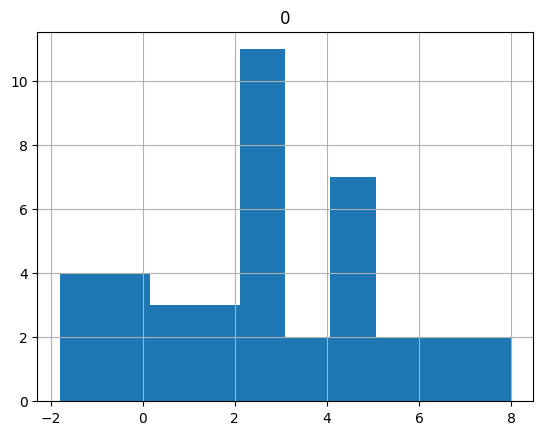

In [84]:
from matplotlib import pyplot
import pandas as pd # Import pandas here if not already imported, or ensure it's imported globally

# calculate residuals
residuals = [x_valid[i]-rnn_forecast[i] for i in range(len(rnn_forecast))]
residuals = pd.DataFrame(residuals)
# histogram plot
residuals.hist()
pyplot.show()

Regression plot

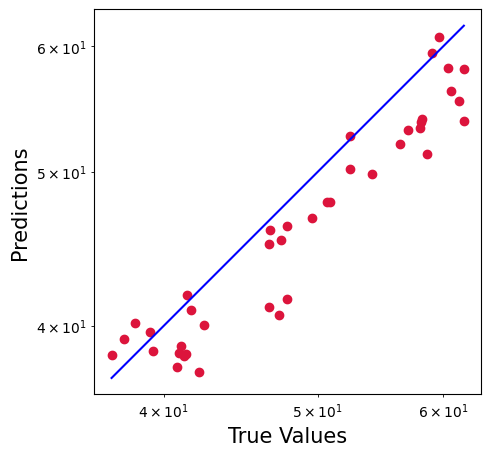

In [85]:
plt.figure(figsize=(5,5))
plt.scatter(x_valid, rnn_forecast, c='crimson')
plt.yscale('log')
plt.xscale('log')

p1 = max(max(rnn_forecast), max(x_valid))
p2 = min(min(rnn_forecast), min(x_valid))
plt.plot([p1, p2], [p1, p2], 'b-')
plt.xlabel('True Values', fontsize=15)
plt.ylabel('Predictions', fontsize=15)
plt.axis('equal')
plt.grid(True)
plt.show()

### Taylor Diagram
A Taylor Diagram is a special type of diagram that summarizes how well a model’s output matches observations using three statistics simultaneously:
*   Correlation coefficient
*   Centered Root Mean Square Error (CRMSE)
*   Standard deviation

In [86]:
pip install skillmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.2/83.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 6.6 MB/s eta 0:00:00


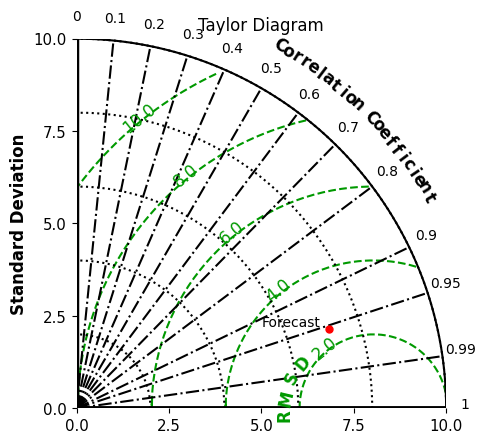

In [87]:
import numpy as np
import matplotlib.pyplot as plt
import skill_metrics as sm

# Data: actual and forecast
x = np.array(x_valid, dtype=np.float64)
y = np.array(rnn_forecast, dtype=np.float64)

# Demean for centered RMSE
x_centered = x - np.mean(x)
y_centered = y - np.mean(y)

# Compute stats
sdev = np.array([np.std(x_centered), np.std(y_centered)], dtype=np.float64)
crmsd = np.array([0, np.sqrt(np.mean((x_centered - y_centered)**2))], dtype=np.float64)
ccoef = np.array([1, np.corrcoef(x_centered, y_centered)[0, 1]], dtype=np.float64)

# Taylor diagram
sm.taylor_diagram(
    sdev, crmsd, ccoef,
    markerLabel=['Observation', 'Forecast'],
    markerSize=10,
    colCOR='black',
    colOBS='red'  # Removed 'styleOBS'
)

plt.title('Taylor Diagram')
plt.show()

## Bland-Altman Plot
The Bland–Altman plot allows to:

* Assess the agreement between two measurements (e.g., actual vs predicted values)

* Visualize the bias and limits of agreement

* Detect systematic errors or outliers in predictions

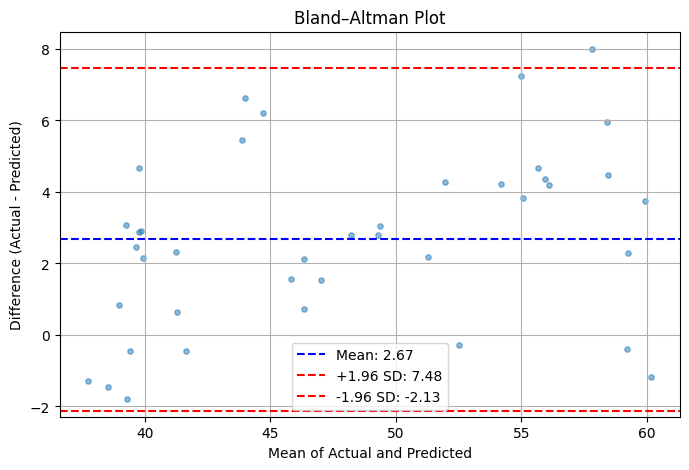

In [88]:
import numpy as np
import matplotlib.pyplot as plt

# x_valid: actual values
# rnn_forecast: predicted values

actual = np.array(x_valid)
predicted = np.array(rnn_forecast)

# Compute averages and differences
avg = (actual + predicted) / 2
diff = actual - predicted
mean_diff = np.mean(diff)
std_diff = np.std(diff)

# Limits of agreement
upper = mean_diff + 1.96 * std_diff
lower = mean_diff - 1.96 * std_diff

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(avg, diff, alpha=0.5, s=15)
plt.axhline(mean_diff, color='blue', linestyle='--', label=f'Mean: {mean_diff:.2f}')
plt.axhline(upper, color='red', linestyle='--', label=f'+1.96 SD: {upper:.2f}')
plt.axhline(lower, color='red', linestyle='--', label=f'-1.96 SD: {lower:.2f}')

plt.title('Bland–Altman Plot')
plt.xlabel('Mean of Actual and Predicted')
plt.ylabel('Difference (Actual - Predicted)')
plt.grid(True)
plt.legend()
plt.show()